#Probabilidade e distribuições

A seguir, vou simular uma base de dados fictícia a partir da qual vamos ver com mais detalhes o que esses conceitos significam.

Vamos supor que essa base é formada pelos dados obtidos a partir das respostas que alunos de uma turma de 33 alunos fornecem ao preencher um formulário. No nosso caso, vermos que nem todos os alunos preenchem o formulário, apenas 20 pessoas preenchem.

In [35]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Garantir reprodutibilidade
np.random.seed(42)

# Gerar 20 linhas de dados
n = 20

# para garanti reprodutibilidade também na data, vou usar uma data base fixa:
data_base = datetime(2026, 6, 29, 17, 0, 0)

data = {
    'horario_registro': [data_base - timedelta(minutes=i*30) for i in range(n)],
    'altura_cm': np.random.randint(150, 200, n),
    'tempo_deslocamento_min': np.random.randint(15, 90, n),
    'qtd_irmaos': np.random.randint(0, 5, n)
}

# DataFrame
df = pd.DataFrame(data)
df['horario_registro'] = pd.to_datetime(df['horario_registro'])

In [36]:
df.dtypes

,0
horario_registro,datetime64[ns]
altura_cm,int64
tempo_deslocamento_min,int64
qtd_irmaos,int64


In [37]:
# tipos de dados
print("Tipos de dados:")
print(df.dtypes)

Tipos de dados:
horario_registro          datetime64[ns]
altura_cm                          int64
tempo_deslocamento_min             int64
qtd_irmaos                         int64
dtype: object


In [38]:
df.shape

(20, 4)

##Describe (descrição estatística)

O comando `.describe()` fornece um resumo estatístico das colunas numéricas de um DataFrame, permitindo compreender rapidamente:

- a escala,
- a tendência central, e,
- a variabilidade das nossas informações.

Cada coluna da tabela (altura_cm, tempo_deslocamento_min, qtd_irmaos) representa uma variável, enquanto cada linha indica uma medida estatística.

In [39]:
df[ ['altura_cm', 'tempo_deslocamento_min', 'qtd_irmaos'] ].describe()

,altura_cm,tempo_deslocamento_min,qtd_irmaos
count,20.000000,20.00000,20.000000
mean,172.850000,58.60000,1.950000
std,13.128013,18.46305,1.431782
min,151.000000,16.00000,0.000000
25%,163.000000,46.25000,1.000000
50%,172.500000,64.00000,2.000000
75%,185.750000,74.00000,3.000000
max,193.000000,78.00000,4.000000


### Interpretando a saída do `.describe()`

Com base nos dados gerados para a nossa amostra de 20 registros, aqui está o que cada métrica nos revela sobre a nossa "turma":

- count (Contagem): Temos exatamente 20 registros em todas as variáveis. Isso confirma que nosso dataset está completo, sem valores ausentes.

- mean (Média): Representa o valor central aritmético. Por exemplo, a altura média da turma é de 172.85 cm, enquanto o tempo médio de deslocamento até o trabalho é de 58.6 minutos.

- std (Desvio Padrão): Indica a dispersão dos dados. Na coluna de altura_cm, temos um desvio de 13.12, o que sugere uma variação razoável entre os alunos. Já na qtd_irmaos, um desvio de 1.43 mostra que a maioria dos alunos tem uma quantidade de irmãos próxima à média.

- min (Mínimo): É o valor mais baixo registrado. Identificamos que o menor tempo de deslocamento foi de 16 minutos e que existem alunos com 0 irmãos.

- 25% (Primeiro Quartil): Este valor delimita que 25% dos alunos possuem, por exemplo, até 163 cm de altura. Abaixo deste ponto, estão os valores mais baixos da amostra.

- 50% (Mediana): Este é o divisor central. Isso significa que metade dos alunos leva até 64 minutos para se deslocar ao trabalho, enquanto a outra metade leva mais que isso.

- 75% (Terceiro Quartil): Indica que 75% dos dados estão abaixo deste valor. Por exemplo, 75% dos alunos possuem até 3 irmãos.

- max (Máximo): É o maior valor encontrado. O maior tempo de deslocamento registrado nesta amostra foi de 78 minutos e a altura máxima atingida foi de 193 cm.

### Histograma e Boxplot

Aqui vamos combinar o histograma com o boxplot: eles são complementares e, juntos, oferecem uma visão muito mais completa da distribuição dos dados.

- O Histograma mostra a "forma" da distribuição (se ela é simétrica, se tem vários picos ou se possui lacunas/gaps entre os grupos).

- O Boxplot resume os pontos de virada (mediana e quartis) e identifica claramente valores destoantes (outliers), que às vezes ficam "escondidos" na cauda de um histograma.

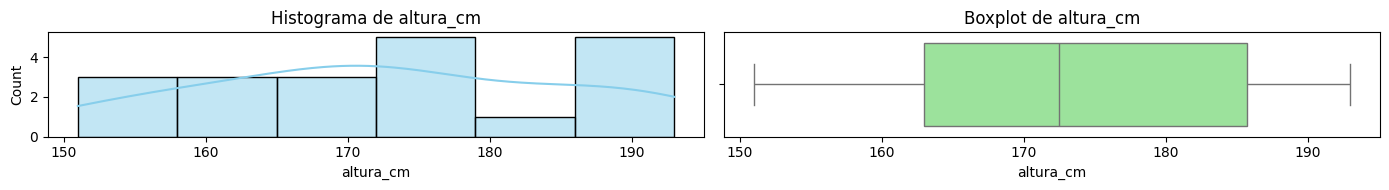

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
# Cria uma figura com 1 linha e 2 colunas
fig, axes = plt.subplots(1, 2, figsize=(14, 2))

# Variável escolhida
var = 'altura_cm'

# Histograma (na primeira posição: axes[0])
sns.histplot(df[var], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title(f'Histograma de {var}')

# Boxplot (na segunda posição: axes[1])
sns.boxplot(x=df[var], ax=axes[1], color='lightgreen')
axes[1].set_title(f'Boxplot de {var}')

plt.tight_layout()
plt.show()

**Histograma**: a altura não segue uma curva perfeita (o sino de Gauss). Há um "vale" ali por volta dos 180cm, indicando uma distribuição um pouco irregular. A linha azul tenta suavizar essa tendência, mostrando que a maior concentração de pessoas está entre 160cm e 175cm.

**Boxplot**: A linha vertical dentro da caixa verde é a sua mediana (o valor de 172.5cm que vimos no describe). Como a caixa está bem centralizada e os "bigodes" (as hastes cinzas) são de tamanhos parecidos, isso indica que não há um desvio extremo para cima ou para baixo; a altura dos alunos está bem distribuída dentro da faixa de 150cm a 195cm.


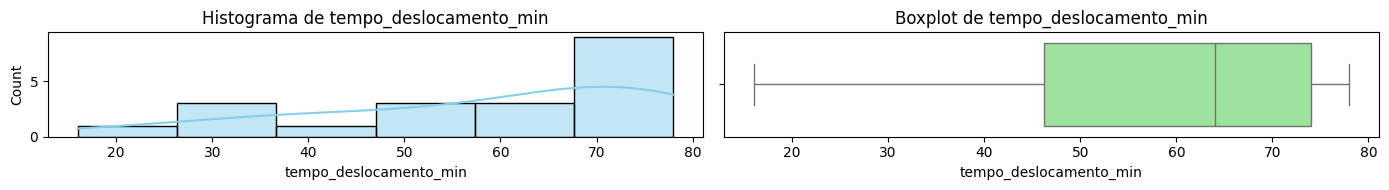

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 2))

var = 'tempo_deslocamento_min'

sns.histplot(df[var], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title(f'Histograma de {var}')

sns.boxplot(x=df[var], ax=axes[1], color='lightgreen')
axes[1].set_title(f'Boxplot de {var}')

plt.tight_layout()
plt.show()

**Histograma**: há uma concentração bem maior de alunos na faixa dos 60 a 80 minutos. Isso sugere que a maioria da turma mora mais longe ou enfrenta um trânsito que exige mais tempo. A inclinação da linha azul mostra que a frequência de alunos aumenta conforme o tempo de deslocamento cresce.

**Boxplot**: note como a caixa verde está "empurrada" para a direita (perto dos 60-70 minutos). Isso confirma visualmente o que vimos no histograma: a mediana (64 minutos) está mais próxima do limite superior (75%). Além disso, o "bigode" esquerdo é bem longo, indicando que existem alguns alunos com tempo de deslocamento muito baixo (perto de 15-20 minutos), mas eles são a minoria.

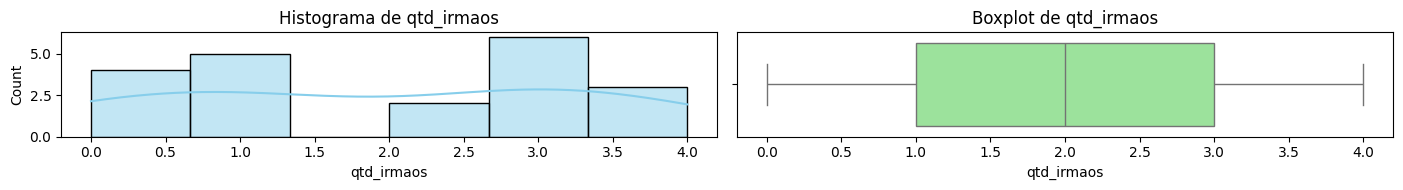

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 2))

var = 'qtd_irmaos'

sns.histplot(df[var], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title(f'Histograma de {var}')

sns.boxplot(x=df[var], ax=axes[1], color='lightgreen')
axes[1].set_title(f'Boxplot de {var}')

plt.tight_layout()
plt.show()

**Histograma e o "Gap"**: entre 1.5 e 2.0 existe uma lacuna onde a contagem é muito baixa ou zero. Isso indica que há um grupo que tem poucos irmãos (0 ou 1) e outro grupo que tem mais (3 ou 4). É uma distribuição "bimodal" (tem dois picos), o que mostra que a turma não se comporta de forma uniforme nessa variável.

**Boxplot**:

- A linha da mediana está cravada no 2.0.

- A caixa verde vai de 1 a 3. Isso significa que 50% dos alunos têm entre 1 e 3 irmãos.

- Os "bigodes" vão de 0 a 4. Isso significa que a amplitude total da turma é de quem não tem nenhum irmão até quem tem 4.

**Importância de observar os dois gráficos**

Como o boxplot **não exibe o "gap"** (a ausência de dados), ele parece sugerir uma distribuição contínua, quando na verdade **o histograma revela** que há uma separação clara entre os subgrupos da turma.

## Fundamentos da incerteza


Segue o nosso primeiro experimento seguindo a lei dos grandes números.

Os conceitos de probabilidade e distribuições servem para nos ajudar a, de maneira geral, medir incertezas. Para conseguirmos medir incertezas, precisamos de dois conceitos: espaço amostral e evento.

O **espaço amostral** (ou amostra) é o conjunto formado por todas as pessoas que responderam o formulário:

In [50]:
# espaço amostral são todas as 20 pessoas
espaco_amostral = df.index.tolist()
espaco_amostral

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]

In [51]:
total_pessoas = len(espaco_amostral)
total_pessoas

20

In [52]:
print(f"Nosso espaço amostral tem {total_pessoas} pessoas.")

Nosso espaço amostral tem 20 pessoas.


#### Evento A: pessoas com exatamente 3 irmãos

Agora, vamos construir um **experimento aleatório**. Num primeiro momento, esse experimento será sortear os alunos que têm exatamente 3 irmão. Podemos ver isso de duas formas: solicitando em quais casos isso ocorre ou não ou selecionando as linhas de dados em que isso ocorre. Uma terceira forma é contando quantas vezes isso ocorre.  As três formas são vistas abaixo.

In [53]:
# Evento A: forma 1
df['qtd_irmaos'] == 3 # o tipo é uma Series booleana

,qtd_irmaos
0,True
1,False
2,False
3,False
4,False
5,False
6,False
7,False
8,True
9,False


In [54]:
# Evento A: forma 2
df[ df['qtd_irmaos'] == 3 ] # o tipo é um Dataframe com os dados do df

,horario_registro,altura_cm,tempo_deslocamento_min,qtd_irmaos
0,2026-06-29 17:00:00,188,44,3
8,2026-06-29 13:00:00,172,36,3
10,2026-06-29 12:00:00,160,73,3
17,2026-06-29 08:30:00,151,76,3
18,2026-06-29 08:00:00,173,65,3
19,2026-06-29 07:30:00,193,69,3


In [55]:
# Evento A: forma 3
(df['qtd_irmaos'] == 3).sum() # o tipo é um int

np.int64(6)

In [56]:
type(df['qtd_irmaos'] == 3)

pandas.core.series.Series

Vamos, por ora, guardar resultado da forma 2 na variável abaixo, observe o tipo:

In [57]:
evento_3_irmaos = df[ df['qtd_irmaos']==3 ]
type(evento_3_irmaos)

pandas.core.frame.DataFrame

O tipo é DataFrame, ou seja, estamos carregando uma "tabela" com todos os dados do `df` que satisfazem a condição de *ter exatamente 3 irmãos*.

### Evento B: alunos com mais de 170 cm de altura

In [58]:
evento_alto = df[ df['altura_cm'] > 170 ]
evento_alto

,horario_registro,altura_cm,tempo_deslocamento_min,qtd_irmaos
0,2026-06-29 17:00:00,188,44,3
1,2026-06-29 16:30:00,178,52,0
3,2026-06-29 15:30:00,192,78,4
6,2026-06-29 14:00:00,188,47,0
8,2026-06-29 13:00:00,172,36,3
11,2026-06-29 11:30:00,173,56,1
12,2026-06-29 11:00:00,185,74,1
13,2026-06-29 10:30:00,189,29,0
14,2026-06-29 10:00:00,173,76,1
16,2026-06-29 09:00:00,171,61,1


## Probabilidades teórica e experimental

Quando calculamos a quantidade de evento específico dividido pelo total de dados estamos calculando a **probabilidade teórica** desse evento acontecer. Uma das formas de fazer essa cálculo é usando:

$$ {\text{Probabilidade de ocorrer um evento do tipo A}} = \frac{{\text{Quantidade de eventos do tipo A}}}{{\text{Quantidade de todos os possíveis eventos}}}{\text{   }}{⇒}{\text{   }}P(A) = \frac{N(A)}{N{(\Omega)}},$$

onde $N(A)$ indica quantas vezes ocorre o evento A e $N{(\Omega)}$ é o tamanho do espaço amostral.


No nosso presente exemplo, podemos fazer o cálculo como segue:

In [59]:
prob_3_irmaos = len(evento_3_irmaos) / len(espaco_amostral)
prob_3_irmaos

0.3

Outra forma de calcular, além do `len()` é usando o `shape`.

In [60]:
prob_3_irmaos = (evento_3_irmaos.shape[0]) / df.shape[0]
print(f"A probabilidade teórica de sortear um aluno com exatamente 3 irmãos é de {prob_3_irmaos:.2f}.")

A probabilidade teórica de sortear um aluno com exatamente 3 irmãos é de 0.30.


Porém nem sempre conseguimos obter uma resposta de forma direta, de modo que é necessário *estimar* qual é a probabilidade de um dado evento ocorrer. Um exemplo disso seria se precisássemos descobrir, entre todos os brasileiros, quantos têm exatamente 3 irmãos. Nesse caso, seria bem difícil entrevistar quase 300 milhões de pessoas.

Nesses casos, os conceitos de **amostra** e **população** são muito úteis.

Uma **amostra** é um conjunto de pessoas, dados, elementos, informações que faz parte de uma **população**.

Ainda considerando a ideia do censo:
- a amostra é a quantidade de pessoas entrevistadas no censo;
- a população terá características estimadas pelos dados da amostra.

Há uma série de condições para evitar que uma amostra apresente resultados enviesados e que seja realmente representativa de uma população, mas não vou falar sobre isso aqui para não fugir do objetivo dessa apresentação introdutória.

Agora considerando o caso da base de dados que estamos trabalhando desde o início deste documento, temos que:

In [61]:
populacao = 33
amostra = df.shape[0]
amostra

20

Note que, de fato, temos um conjunto de 20 registros, ou seja, 20 respostas coletadas. Sendo assim, a amostra tem tamanho 20. Como foi mencionado no início do documento, estamos considerando que apenas 20 pessoas de uma turma de 33 pessoas enviou as respostas à esse formulário, de modo que a população tem tamanho 33. Portanto, o resultado `prob_3_irmaos = 0.30` se refere às respostas vindas dessa amostra, mas, ao mesmo tempo, isso é uma estimativa, já que nem todas as 33 pessoas responderam o formulário.

Neste caso, assim como no caso do censo, podemos usar o conceito de **probabilidade experimental**, que consiste em calcular essa probabilidade considerando amostras (ou sorteios) diferentes produzindo a probabilidade estimada.

### Probabilidade experimental

Na probabilidade teórica dividimos N(A), que é o número de vezes que ocorre um evento A, pelo tamanho fixo do espaço amostral. Mas há casos em que não temos acesso ao tamanho total do espaço amostral, como, por exemplo: sendo A o evento que representa o caso de uma pessoa ter exatamente 3 irmãos, como calcular a probabilidade de ocorrência de A quando o espaço amostral é toda a população brasileira?

Em casos como esses, em que não temos acesso ao espaço amostral como um todo, precisamos olhar para o conjunto de dados disponível e verificar a ocorrência do evento de interesse. Em outras palavras: precisamos sortear um elemento do conjunto de dados um número $n$ de vezes e contar quantas vezes esse evento ocorre dentre os $n$ sorteios.

À essa divisão damos o nome de **Frequência relativa** $f_{n}(A)$, cuja expressão matemática é:

$$f_{n}(A) = \frac{N_A}{n},$$

sendo $N_A$ é o número de vezes que ocorre o evento A e $n$ é o número de repetições do experimento aleatório (ou número de sorteios).

A tabela abaixo mostra a diferença entre os termos que definem as probabilidades teórica e experimental.


| Conceito    | Teórica                          | Experimental (Simulada)                                                 |
| ----------- | -------------------------------- | -------------------------------------------------------- |
| Numerador   | número de alunos com 3 irmãos    | número de sorteios que resultaram em alguém com 3 irmãos |
| Denominador | número de alunos do DataFrame    | número de sorteios realizados                            |
| Resultado   | probabilidade exata do DataFrame | aproximação da probabilidade                             |


Essa frequência relativa é a estimativa empírica da probabilidade teórica, aproximando-se desta à medida que o número de tentativas aumenta.

Essa constatação foi resumida na chamada **Lei dos Grandes Números**, que diz que:

> **Lei dos Grandes Números**
>
> Conforme aumentamos a quantidade de observações (ou sorteios), nossa estimativa tende a se aproximar da probabilidade teórica (verdadeira).

Em termos formais, a Lei dos Grandes números significa que:

$$f_{n}(A){\text{  }}{→}{\text{  }}P(A){\text{     quando    }}n{→}{∞}.$$

A esses sorteios chamamos **Experimento Aleatório**.

Vamos simular o funcionamento dessa lei seguindo os comando abaixo, sendo:

- **Experimento Aleatório:** sortear aleatoriamente um aluno da nossa turma a partir dos dados do `df`.

- **Espaço Amostral ($\Omega$):** o `df`, com todos os alunos que responderam à pesquisa. Nosso universo tem 20 resultados possíveis.

- **Evento (A):** no nosso caso, evento A será 'sortear um aluno que tem 3 irmãos'. Em outros casos, o evento pode ser outra coisa.

Para sortear, vamos usar o método `.sample()`. Vamos fazer 10.000 sorteios sobre o nosso `df`.

Vejamos no comando abaixo como ocorreria um sorteio:

In [62]:
aluno_sorteado = df.sample(n=1) # o retorno é tipo DataFrame
aluno_sorteado

,horario_registro,altura_cm,tempo_deslocamento_min,qtd_irmaos
15,2026-06-29 09:30:00,152,76,4


Agora vamos resumir o `aluno_sorteado` acima que está com typo `DataFrame` em tipo `Series`, para ajudar no comando subsequente:

In [63]:
aluno_sorteado['qtd_irmaos'] # o retorno é tipo Series

,qtd_irmaos
15,4


In [64]:
aluno_sorteado['qtd_irmaos'].iloc[0] == 3

np.False_

Simulando a Lei dos Grandes Números para sortear uma pessoa com exatamente 3 irmãos. Agora vamos fazer vários sorteios e acumular (contar, somar) os resultados numa variável de contagem, a `contagem_3_irmaos`:

In [65]:
num_sorteio = 10000 # esse é o tamanho da AMOSTRA; podemos variar esse número; quanto maior, mais precisa é a probabilidade
contagem_3_irmaos = 0 # contador que irá armazenar o número de vezes em que uma dada pessoa realmente tem 3 irmãos

for _ in range(num_sorteio):
  aluno_sorteado = df.sample(n=1) # sorteando uma linha aleatória do df
  if aluno_sorteado['qtd_irmaos'].iloc[0] == 3:
    contagem_3_irmaos += 1

prob_experimental_3_irmaos = contagem_3_irmaos / num_sorteio
prob_experimental_3_irmaos

0.2989

In [66]:
print(f"Sorteamos um aluno {num_sorteio} vezes.")
print(f"A partir desses sorteios, em {contagem_3_irmaos} vezes o aluno possuía exatamente 3 irmãos.")
print(f"A probabilidade SIMULADA, e não a teórica, de ter 3 irmãos foi de: {prob_experimental_3_irmaos}.")

Sorteamos um aluno 10000 vezes.
A partir desses sorteios, em 2989 vezes o aluno possuía exatamente 3 irmãos.
A probabilidade SIMULADA, e não a teórica, de ter 3 irmãos foi de: 0.2989.


Veja que o resultado foi bem próximo da probabilidade teórica de 0.30.

**Novo exemplo**

Agora vamos calcular a probabilidade teórica e experimental de um evento B, sendo B o evento de sortear pessoas com mais de 170 cm de altura, dentro do nosso `df`.

In [67]:
num_sorteio_B = 10000
contagem_alto = 0

for _ in range(num_sorteio_B):
  aluno_sorteado_B = df.sample(n=1)
  if aluno_sorteado_B['altura_cm'].iloc[0] > 170:
    contagem_alto += 1

prob_experimental_alto = contagem_alto / num_sorteio_B
prob_experimental_alto

0.6028

Note que essa probabilidade é bem próxima da teórica, que calculamos mais acima neste documento:

In [68]:
prob_teorica_alto = len(evento_alto) / len(espaco_amostral)
prob_teorica_alto

0.6

## Probabilidade Condicional e Independência

Quando lidamos com mais de uma condição, surge o conceito de Probabilidade condicional. Nesse caso, estaremos lidando com um espaço amostral que possa satisfazer essas condições.

Consideremos o caso em que queiramos identificar alunos que são altos e que também tenham exatamente 3 irmãos. Nesse caso, nosso novo espaço amostral será menor, já que a adição de uma ou mais condição restringe o universo de análise:

In [69]:
# Probabilidade condicional de aluno alto & tem exatamente 3 irmãos
novo_espaco_amostral = evento_alto
print(f"Novo universo (alunos altos): {len(novo_espaco_amostral)} alunos.")

Novo universo (alunos altos): 12 alunos.


Não estamos mais olhando para os 20 alunos, mas apenas para o grupo dos 12 alunos altos. Esse é o nosso novo denominador.

Dentro desse novo universo, quantos têm exatamente 3 irmãos?

In [70]:
novo_espaco_amostral['qtd_irmaos'] == 3 # retorna uma Series (pois é filtro booleano)

,qtd_irmaos
0,True
1,False
3,False
6,False
8,True
11,False
12,False
13,False
14,False
16,False


In [71]:
novo_espaco_amostral[ novo_espaco_amostral['qtd_irmaos'] == 3 ] # retorna df que satisfaz a segunda condição

,horario_registro,altura_cm,tempo_deslocamento_min,qtd_irmaos
0,2026-06-29 17:00:00,188,44,3
8,2026-06-29 13:00:00,172,36,3
18,2026-06-29 08:00:00,173,65,3
19,2026-06-29 07:30:00,193,69,3


Respondendo a pergunta:

In [28]:
num_casos_favoraveis = len( novo_espaco_amostral[ novo_espaco_amostral['qtd_irmaos'] == 3 ])
print(f"Dentre os alunos altos, há {num_casos_favoraveis} alunos que têm exatamente 3 irmãos.")

Dentre os alunos altos, há 4 alunos que têm exatamente 3 irmãos.


Agora, para calcular a probabilidade condicional de quantos alunos altos também têm exatamente 3 irmãos, fazemos:

In [72]:
prob_condicional_teorica = num_casos_favoraveis / len(novo_espaco_amostral)

print(f"ter 3 irmãos | ser alto é: {prob_condicional_teorica:.2f}")

ter 3 irmãos | ser alto é: 0.33


Logo:

$$P(\text{ter 3 irmãos | ser alto}) = \frac{4}{12} {\approx} {\text{  }}0.33 {\text{  ou  33.33%}}$$

Isso sugere que, na nossa turma, ser alto torna um pouco menos provável ter 3 irmãos.

Portantouando a gente empilha/agrega condições, alteramos as possibilidades teóricas iniciais, diferentemente do que vimos no início, em que não havia dependência de novas condições.

## Variáveis Aleatórias e Distribuições

Vamos construir a distribuição de qtd_irmaos com os novos valores de probabilidade.

Lembrando dos resultados do `.describe()`, vimos que os alunos que preencheram o formulário têm entre 0 e 4 irmãos. Vamos contar quantos alunos têm 0, quantos têm 1,..., e quantos têm 4 irmãos. Sabendo esses valores, podemos calcular a probabilidade de ter de 0 a 4 irmãos:

In [81]:
# contagem original de irmãos (frequência absoluta)
contagem = df['qtd_irmaos'].value_counts().sort_index()
contagem

,count
qtd_irmaos,
0,4
1,5
2,2
3,6
4,3


Para calcular em termos percentuais, temos:

In [83]:
# proporção em termos percentuais (frequência relativa)
proporcao = df['qtd_irmaos'].value_counts(normalize=True).sort_index()
proporcao

,proportion
qtd_irmaos,
0,0.20
1,0.25
2,0.10
3,0.30
4,0.15


Vamos unificar essas duas informações em um DataFrame, já que as duas variáveis acima são tipo Series:

In [86]:
# Juntando as duas informações em um novo DataFrame
df_resultado = pd.DataFrame({
    'Contagem': contagem,
    'Proporção': proporcao
})

df_resultado

,Contagem,Proporção
qtd_irmaos,,
0,4,0.20
1,5,0.25
2,2,0.10
3,6,0.30
4,3,0.15


Adicionando uma coluna de Porcentagem para melhor visualização:

In [88]:
df_resultado['Porcentagem'] = df_resultado['Proporção'] * 100
df_resultado

,Contagem,Proporção,Porcentagem
qtd_irmaos,,,
0,4,0.20,20.0
1,5,0.25,25.0
2,2,0.10,10.0
3,6,0.30,30.0
4,3,0.15,15.0


Usando as frequências que calculamos acima com Python e considerando X o evento de ter x irmãos, com x de 0 até 4, os resultados que obtivemos acima podem ser resumidos na notação equivalente de probabilidade:

$$P(X = 0) = 4/20 = 20\%$$

$$P(X = 1) = 5/20 = 25\%$$

$$P(X = 2) = 2/20 = 10\%$$

$$P(X = 3) = 6/20 = 30\%$$

$$P(X = 4) = 3/20 = 15\%$$

Agora vou plotar um gráfico de barras para vermos a distribuição de probabilidade da variável 'qtd_irmaos':


--- Distribuição de Probabilidade para 'Quantidade de Irmãos' ---
qtd_irmaos
0    0.20
1    0.25
2    0.10
3    0.30
4    0.15
Name: proportion, dtype: float64


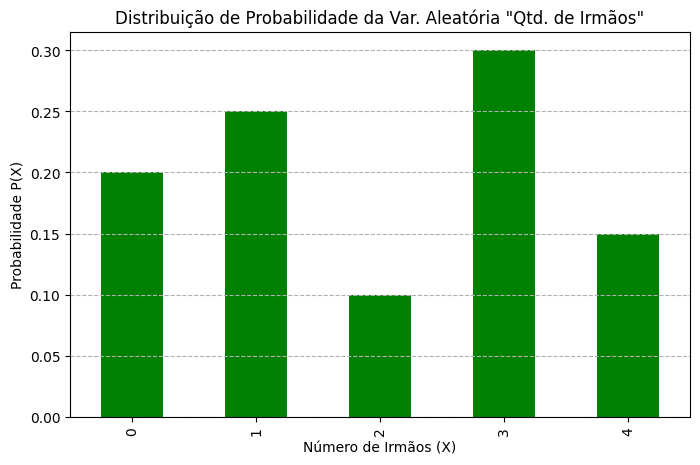

In [93]:
distribuicao_prob_irmaos = df['qtd_irmaos'].value_counts(normalize=True).sort_index()

print("--- Distribuição de Probabilidade para 'Quantidade de Irmãos' ---")
print(distribuicao_prob_irmaos)

distribuicao_prob_irmaos.plot(kind='bar', figsize=(8, 5), color='green') # 'bar' é gráfico de barras
plt.title('Distribuição de Probabilidade da Var. Aleatória "Qtd. de Irmãos"')
plt.xlabel('Número de Irmãos (X)')
plt.ylabel('Probabilidade P(X)')
plt.grid(axis='y', linestyle='--')
plt.show()

O gráfico reforça os resultados obtidos logo acima. Ao sortearmos uma pessoa no nosso conjunto de dados de 20 alunos, podemos dizer que:

- a probabilidade de a pessoa sorteada ter 1 irmão é de 25%;
- a probabilidade de a pessoa sorteada ter 3 irmãos é de 30%;

e assim por diante.

Uma constatação importante:

> A **Distribuição de Probabilidade** de uma variável é exatamente a **Frequência Relativa** dessa variável quando montamos a tabela de frequência dela.